In [9]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [10]:
DATA_DIRECTORY = "./data"
DETAILED_PLOTS_DIR = "runs_and_average_plots"
ARRAY_SIZES = np.arange(500, 100000, 100)

In [11]:
def parse_filename(filename):
    pattern = re.compile(
        r"(merge_sort|merge_insertion_sort)_"
        r"(fully_random|reverse_random|almost_random)_"
        r"(?:threshold_(\d+)_)?run_(\d+)\.txt"
    )
    match = pattern.match(filename)

    if not match:
        return None

    sort_type, array_type, threshold, run = match.groups()

    threshold = int(threshold) if threshold else 0

    return {
        "sort_type": sort_type,
        "array_type": array_type.replace("_", " ").title(),
        "threshold": threshold,
        "run": int(run),
    }

In [12]:
def load_data(directory):
    all_records = []

    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            params = parse_filename(filename)
            if params:
                filepath = os.path.join(directory, filename)
                times_ms = pd.read_csv(filepath, header=None, names=["time_ms"])

                times_ms["size"] = ARRAY_SIZES
                for key, value in params.items():
                    times_ms[key] = value

                all_records.append(times_ms)

    return pd.concat(all_records, ignore_index=True)


In [13]:
def plot_threshold_comparison(data):
    mis_data = data[data["sort_type"] == "merge_insertion_sort"].copy()

    palette = sns.color_palette("viridis", n_colors=mis_data["threshold"].nunique())

    for array_type in mis_data["array_type"].unique():
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, ax = plt.subplots(figsize=(12, 8))

        subset = mis_data[mis_data["array_type"] == array_type]

        sns.lineplot(
            data=subset,
            x="size",
            y="time_ms",
            hue="threshold",
            palette=palette,
            ax=ax,
            errorbar=None,
            alpha=0.9,
        )

        ax.set_title(
            f'MergeInsertionSort: Threshold Performance on "{array_type}" Data',
            fontsize=20,
            fontweight="bold",
        )
        ax.set_xlabel("Array Size", fontsize=16)
        ax.set_ylabel("Average Time (milliseconds)", fontsize=16)
        ax.tick_params(axis="both", which="major", labelsize=12)
        ax.legend(title="Threshold", fontsize=12)

        filename = f"threshold_comparison_{array_type.replace(' ', '_').lower()}.png"
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)

In [14]:
def plot_all_algorithms(data):
    data["algorithm"] = data.apply(
        lambda row: "MergeSort"
        if row["sort_type"] == "merge_sort"
        else f"MergeInsertionSort (th={row['threshold']})",
        axis=1,
    )

    for array_type in data["array_type"].unique():
        plt.style.use("seaborn-v0_8-whitegrid")
        fig, ax = plt.subplots(figsize=(12, 8))

        subset = data[data["array_type"] == array_type]

        sns.lineplot(
            data=subset,
            x="size",
            y="time_ms",
            hue="algorithm",
            ax=ax,
            errorbar=None,
            alpha=0.9
        )

        ax.set_title(
            f'Overall Performance on "{array_type}" Data',
            fontsize=20,
            fontweight="bold",
        )
        ax.set_xlabel("Array Size", fontsize=16)
        ax.set_ylabel("Average Time (milliseconds)", fontsize=16)
        ax.tick_params(axis="both", which="major", labelsize=12)
        ax.legend(title="Algorithm", fontsize=12)

        filename = f"all_algorithms_{array_type.replace(' ', '_').lower()}.png"
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)


In [15]:
def plot_runs_and_average(data, directory):
    os.makedirs(directory, exist_ok=True)

    data["algorithm"] = data.apply(
        lambda row: "MergeSort"
        if row["sort_type"] == "merge_sort"
        else f"MergeInsertionSort_th_{row['threshold']}",
        axis=1,
    )

    for array_type in data["array_type"].unique():
        for algorithm in data["algorithm"].unique():
            subset = data[
                (data["array_type"] == array_type) & (data["algorithm"] == algorithm)
            ]

            if subset.empty:
                continue

            plt.style.use("seaborn-v0_8-whitegrid")
            fig, ax = plt.subplots(figsize=(12, 8))

            sns.lineplot(
                data=subset,
                x="size",
                y="time_ms",
                hue="run",
                palette="Greys_d",
                linewidth=1,
                alpha=0.8,
                legend=True,
                ax=ax,
            )

            sns.lineplot(
                data=subset,
                x="size",
                y="time_ms",
                color="red",
                linewidth=2,
                label="Average",
                ax=ax,
                errorbar=None,
            )

            title_alg = (
                algorithm.replace("_", " ").replace(" th ", " (th=") + ")"
                if "th" in algorithm
                else algorithm
            )
            ax.set_title(
                f'Performance of {title_alg} on "{array_type}" Data',
                fontsize=20,
                fontweight="bold",
            )
            ax.set_xlabel("Array Size", fontsize=16)
            ax.set_ylabel("Time (milliseconds)", fontsize=16)
            ax.tick_params(axis="both", which="major", labelsize=12)

            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles[-6:], labels[-6:], title="Run / Average")

            filename_alg = algorithm.replace(" ", "_").lower()
            filename_arr = array_type.replace(" ", "_").lower()
            filename = os.path.join(
                directory, f"{filename_alg}_on_{filename_arr}.png"
            )

            plt.savefig(filename, dpi=300, bbox_inches="tight")
            plt.close(fig)

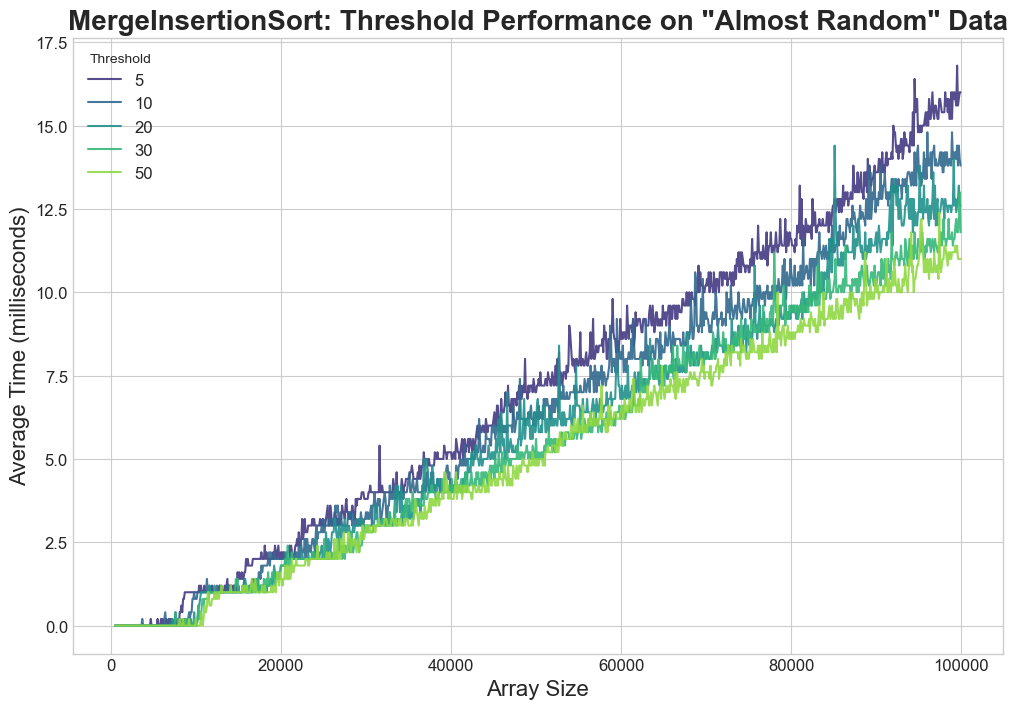

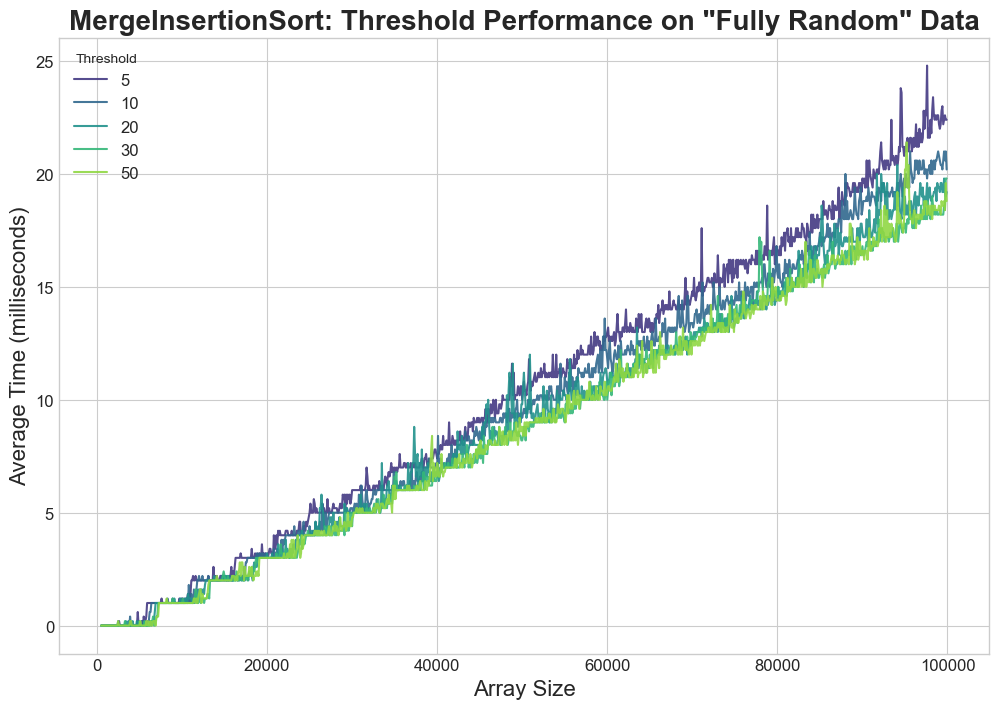

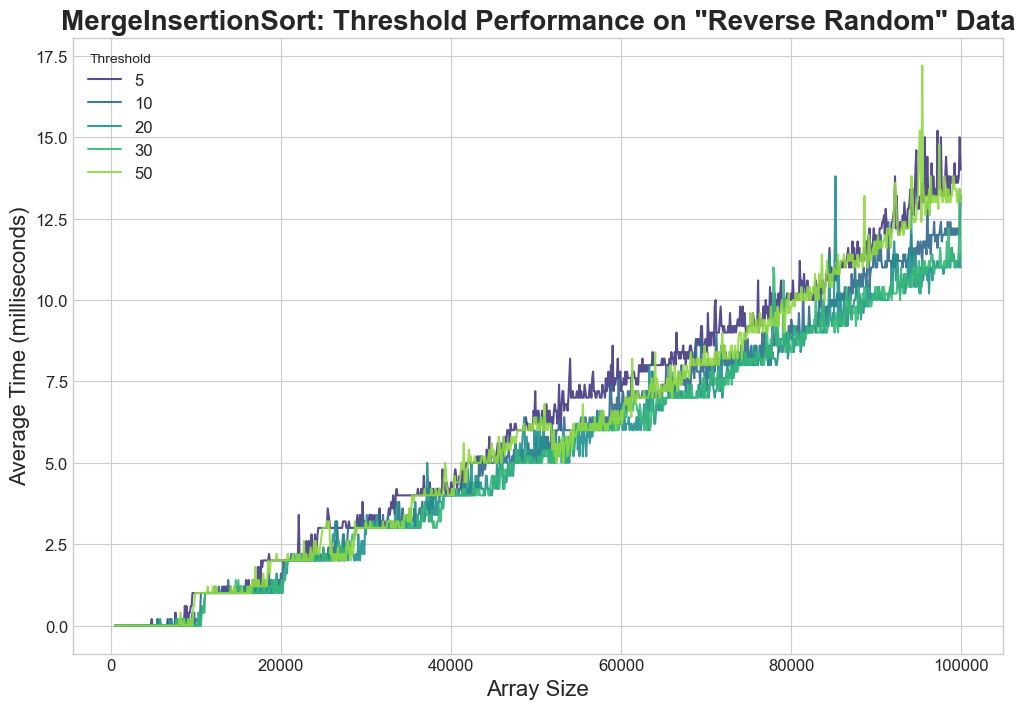

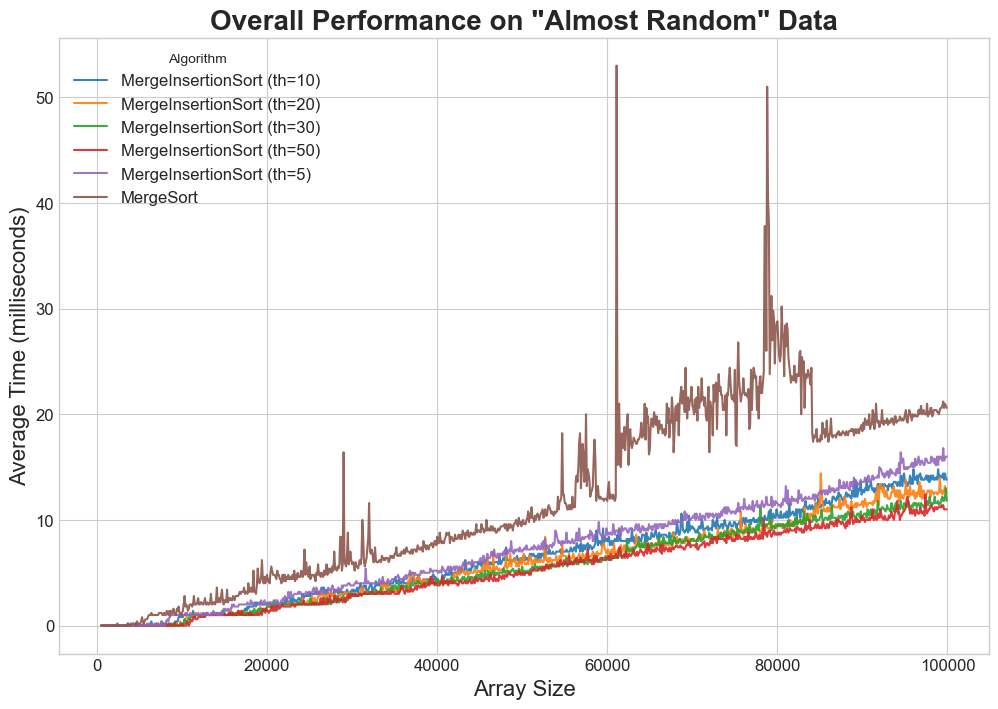

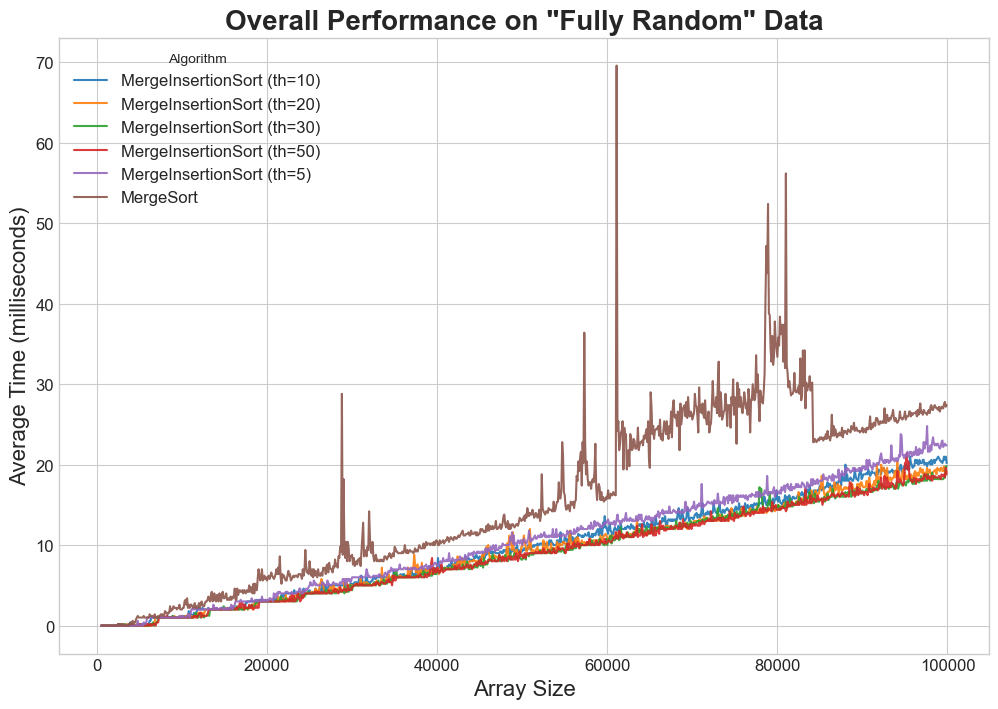

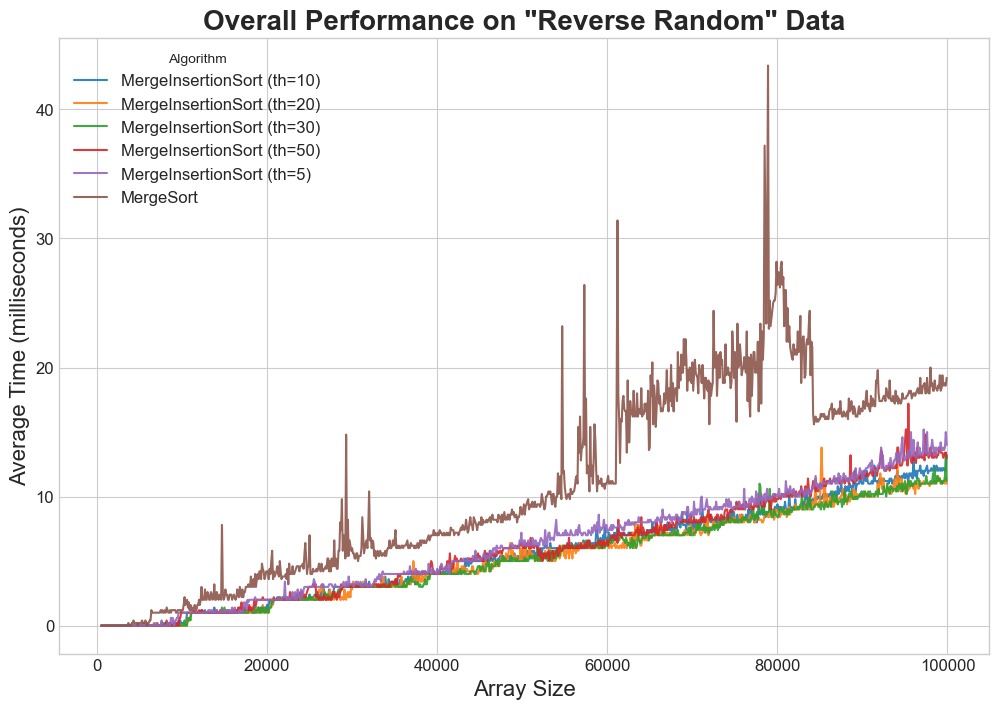

In [16]:
raw_data = load_data(DATA_DIRECTORY)

plot_threshold_comparison(raw_data.copy())
plot_all_algorithms(raw_data.copy())
plot_runs_and_average(raw_data.copy(), DETAILED_PLOTS_DIR)